### ДЗ 3 — ансамбль, подбор гиперпараметров и интерпретация

**Датасет и постановка** - Breast Cancer Wisconsin (Diagnostic), бинарная классификация (`M` / `B`). Столбец `id` не входит в признаки.

**Метрика**: основная — **recall по классу `M`** (минимизировать пропуск злокачественных случаев). Дополнительно: precision и F2 по `M`.


#### План работы

1. **Сложная модель:** градиентный бустинг по деревьям - `HistGradientBoostingClassifier` (ансамбль деревьев, сильнее одного дерева / простой линейной модели).
2. **Подбор гиперпараметров:** `RandomizedSearchCV` + стратифицированная **5-fold** кросс-валидация, целевая метрика в CV - `recall` (полнота по положительному классу `M` ≡ метка `1`).
3. **Обучение:** лучшая конфигурация переобучается на всём train (`refit=True` по умолчанию).
4. **Отложенная выборка:** качество на том же `test`, что и в ДЗ 2 (`test_size=0.2`, `stratify`, `random_state=42`).
5. **Интерпретация:** глобально - важности признаков модели, `permutation_importance`, summary plot SHAP, локально - waterfall SHAP для отдельных объектов.

## 1) Зависимости, импорты и воспроизводимость

`shap` не входит в минимальный состав scikit-learn, при первом запуске в чистом окружении ячейка с `%pip install` подтянет пакет (флаг `-q` уменьшает вывод).


In [ ]:
%pip install -q shap

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from scipy.stats import randint, uniform
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report,
    fbeta_score,
    precision_score,
    recall_score,
)

RANDOM_STATE = 42
CV_SPLITS = 5
N_SEARCH_ITER = 35

warnings.filterwarnings("ignore", category=UserWarning)

print("OK")

OK


## 2) Данные

Те же 30 признаков в порядке UCI, в sklearn код `0` = malignant = `M`, `1` = benign = `B`.


In [ ]:
from sklearn.datasets import load_breast_cancer

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

FEATURE_COLS = [
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean", "concave points_mean",
    "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se", "concave points_se",
    "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst", "concave points_worst",
    "symmetry_worst", "fractal_dimension_worst",
]
COLUMN_NAMES = ["id", "diagnosis"] + FEATURE_COLS

try:
    df = pd.read_csv(DATA_URL, header=None, names=COLUMN_NAMES).dropna(axis=1, how="all")
    print("Source:", DATA_URL, df.shape)
except Exception as err:
    print("UCI недоступен (%s): sklearn.datasets.load_breast_cancer" % type(err).__name__)
    bc = load_breast_cancer()
    df = pd.DataFrame(bc.data, columns=FEATURE_COLS)
    df.insert(0, "diagnosis", np.where(bc.target == 0, "M", "B"))
    df.insert(0, "id", np.arange(1, len(df) + 1))
    print("Shape:", df.shape)

df.head()

Source: https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3) Признаки, таргет и разбиение train / test

Используется фиксированная схема разбиения train/test, чтобы оценка на отложенной выборке была корректной, воспроизводимой и сопоставимой между моделями.

Для деревьев и бустинга **масштабирование не обязательно** (сплиты инвариантны к монотонным преобразованиям каждого признака), подаём сырые числовые признаки.


In [ ]:
target_col = "diagnosis"
id_col = "id" if "id" in df.columns else None
feature_cols = [c for c in df.columns if c not in {target_col, id_col}]
X = df[feature_cols].copy()
y = (df[target_col] == "M").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train M=1 share:", y_train.mean().round(4))

X_train: (455, 30)  X_test: (114, 30)
y_train M=1 share: 0.3736


### Вывод

Разбиение выполнено корректно: получены обучающая и тестовая выборки размером 455 и 114 объектов соответственно, каждая с 30 признаками. Благодаря стратификации `(stratify=y)` доля положительного класса `M` в `train (0.3736)` сохраняет исходный баланс классов, что обеспечивает корректную и репрезентативную оценку модели на отложенной выборке.



## 4) Ансамбль и подбор гиперпараметров на кросс-валидации

**Почему `HistGradientBoostingClassifier`:** это ансамбль слабых учеников (деревья), даёт нелинейные границы и обычно сильнее логрег на табличных данных; реализация sklearn быстрее классического `GradientBoostingClassifier` на больших `n_samples`.

**Что оптимизируем и зачем:**

- `learning_rate` и `max_iter` — баланс скорости обучения и риска недо-/переобучения.
- `max_depth` / `max_leaf_nodes` — сложность каждого дерева.
- `min_samples_leaf` — регуляризация через минимальный размер листа.
- `l2_regularization` — штраф к весам листьев в библиотечной постановке HGB.

**Почему `RandomizedSearchCV`, а не полный перебор:** пространство параметров большое; случайный поиск по фиксированному числу итераций (`N_SEARCH_ITER`) даёт хороший компромисс качество/время на учебном датасете.

**Почему `scoring="recall"`:** в бинарной задаче с метками `0`/`1` это recall положительного класса, то есть как раз **Recall(M)**.


In [5]:
base_estimator = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)

param_distributions = {
    "max_iter": randint(100, 450),
    "learning_rate": uniform(0.03, 0.22),
    "max_depth": randint(3, 12),
    "min_samples_leaf": randint(5, 45),
    "max_leaf_nodes": randint(20, 64),
    "l2_regularization": uniform(0.0, 0.8),
}

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=base_estimator,
    param_distributions=param_distributions,
    n_iter=N_SEARCH_ITER,
    scoring="recall",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

print("Best CV recall (mean):", round(search.best_score_, 4))
print("Best params:", search.best_params_)

Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best CV recall (mean): 0.9412
Best params: {'l2_regularization': np.float64(0.31094183175158563), 'learning_rate': np.float64(0.0896967869902571), 'max_depth': 7, 'max_iter': 379, 'max_leaf_nodes': 45, 'min_samples_leaf': 29}


### Вывод

Подбор гиперпараметров выполнен корректно с помощью `RandomizedSearchCV` на стратифицированной 5-fold кросс-валидации по метрике recall. По итогам 175 обучений получена лучшая средняя полнота `Recall(M)=0.9412`, что указывает на высокую способность модели находить объекты класса M. Оптимальные параметры задают сбалансированную по сложности и регуляризации конфигурацию, которая затем используется как финальная модель `(best_estimator_)` для оценки на отложенной выборке.






## 5) Качество на отложенной выборке (test)

Модель с лучшими параметрами уже дообучена на **всем** `X_train` после поиска. Оцениваем только на `X_test` (данные test не участвовали в выборе гиперпараметров).


In [6]:
y_pred = best_model.predict(X_test)

recall_m = recall_score(y_test, y_pred, pos_label=1)
precision_m = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
f2_m = fbeta_score(y_test, y_pred, beta=2, pos_label=1, zero_division=0)

print(f"Recall(M):    {recall_m:.4f}")
print(f"Precision(M): {precision_m:.4f}")
print(f"F2(M):        {f2_m:.4f}")
print("\n", classification_report(
    y_test, y_pred, target_names=["B (0)", "M (1)"], zero_division=0,
))

Recall(M):    0.9286
Precision(M): 1.0000
F2(M):        0.9420

               precision    recall  f1-score   support

       B (0)       0.96      1.00      0.98        72
       M (1)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### Вывод

Оценка на отложенной выборке показывает высокое качество модели: `Recall(M)=0.9286`, `Precision(M)=1.0000`, `F2(M)=0.9420`. Модель обнаруживает большинство злокачественных случаев (39 из 42), при этом не допускает ложных срабатываний по классу `M`. Таким образом, итоговая модель обеспечивает сильный баланс между клинически важной полнотой и точностью и может считаться успешной в рамках поставленной задачи.

## 6) Глобальная интерпретация модели

Три взгляда:

1. **Глобальные важности признаков:** либо `feature_importances_` у HGB (если есть в вашей версии sklearn), либо среднее `permutation_importance` на **train** — оба отражают относительный вклад признаков.
2. **Permutation importance** на `test` (с разбросом по повторам): насколько падает recall при перемешивании признака.
3. **SHAP** (TreeExplainer): распределение SHAP-значений по выборке — направление и сила влияния на **логит / выход** модели.

Для SHAP на полном `test` строим summary на подвыборке (скорость и читаемость графика); при необходимости увеличьте `N_SHAP`.


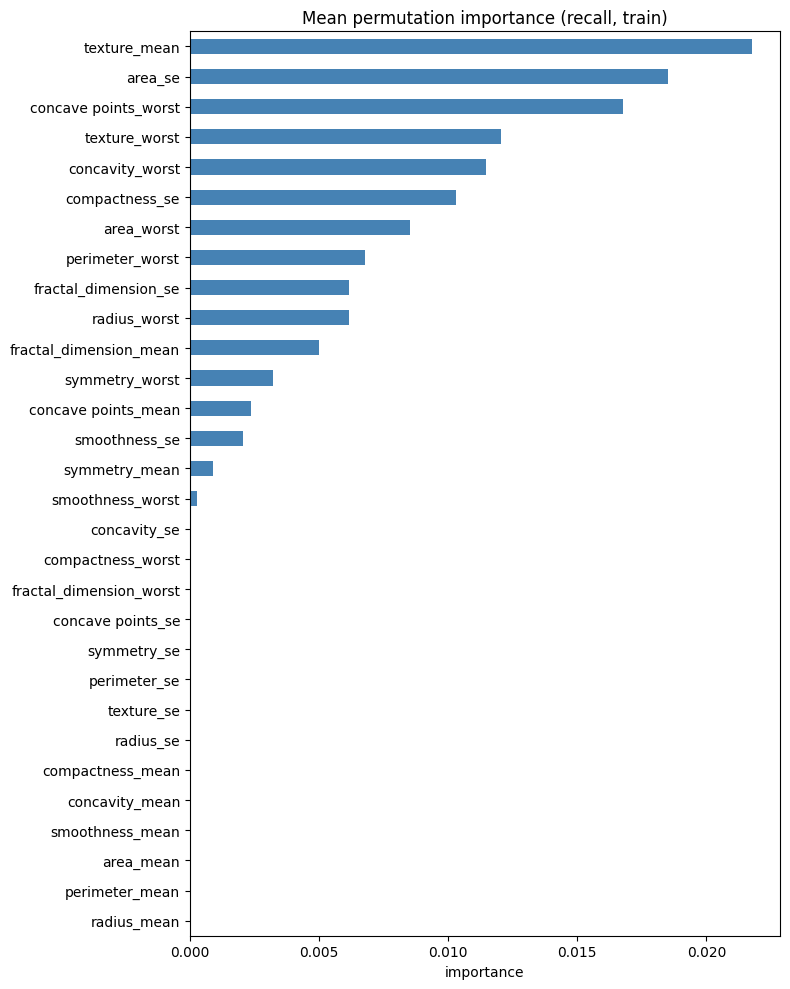

In [7]:
if hasattr(best_model, "feature_importances_"):
    feat_imp = pd.Series(best_model.feature_importances_, index=feature_cols)
    title = "HistGradientBoosting: feature_importances_"
else:
    perm_train = permutation_importance(
        best_model,
        X_train,
        y_train,
        n_repeats=20,
        random_state=RANDOM_STATE,
        scoring="recall",
        n_jobs=-1,
    )
    feat_imp = pd.Series(perm_train.importances_mean, index=feature_cols)
    title = "Mean permutation importance (recall, train)"

feat_imp_sorted = feat_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
feat_imp_sorted.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(title)
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

На графике показана средняя `permutation importance` признаков на обучающей выборке по метрике recall. Наибольший вклад в полноту по классу `M` вносят признаки `texture_mean`, `area_se` и `concave points_worst`, признаки с важностью, близкой к нулю, практически не влияют на итоговое решение модели.

/tmp/ipykernel_24522/240954103.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


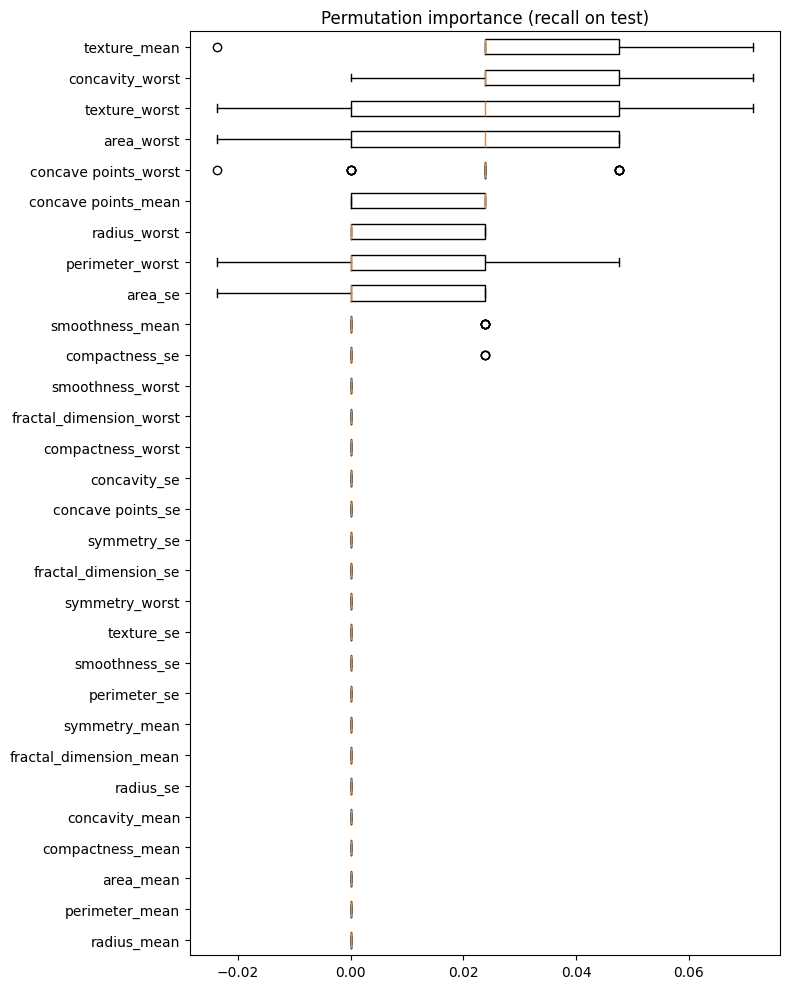

In [8]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=25,
    random_state=RANDOM_STATE,
    scoring="recall",
    n_jobs=-1,
)

perm_sorted_idx = perm.importances_mean.argsort()
fig, ax = plt.subplots(figsize=(8, 10))
ax.boxplot(
    perm.importances[perm_sorted_idx].T,
    vert=False,
    labels=np.array(feature_cols)[perm_sorted_idx],
)
ax.set_title("Permutation importance (recall on test)")
plt.tight_layout()
plt.show()

`Permutation importance` на тестовой выборке показывает, что наибольший вклад в `Recall(M)` вносят признаки `texture_mean`, `concavity_worst`, `texture_worst` и `area_worst`: их перемешивание заметно снижает полноту модели. Большинство остальных признаков имеют важность около нуля, то есть почти не влияют на итоговый recall. Для ряда топ-признаков наблюдается разброс по повторам, но медианная важность остаётся положительной, что подтверждает их устойчивую значимость.

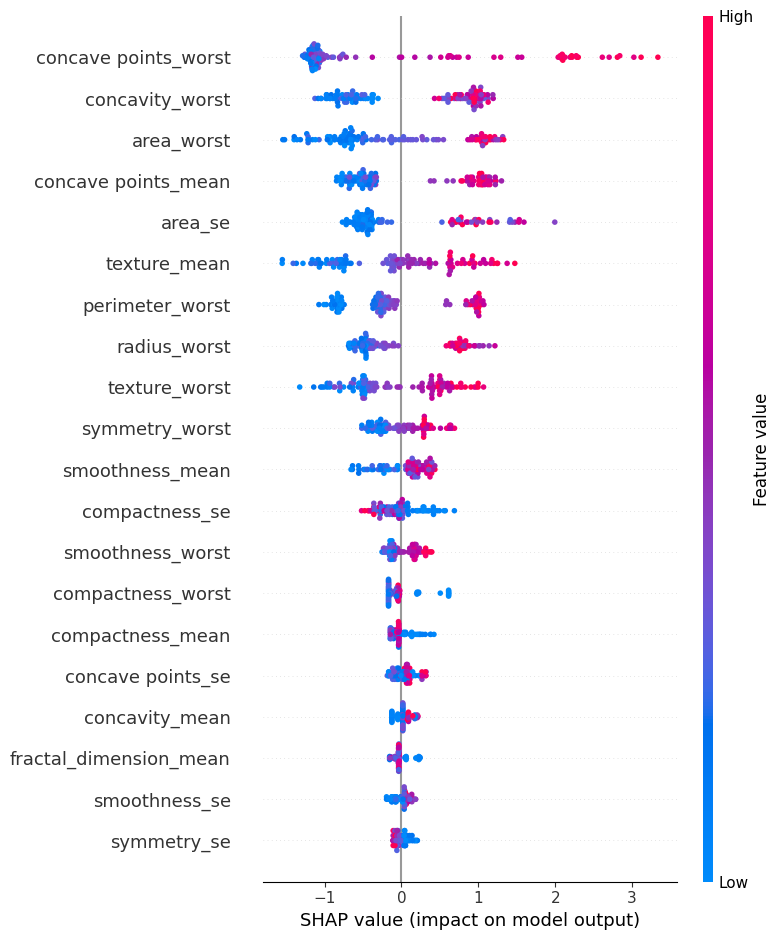

In [9]:
N_SHAP = min(400, len(X_test))
X_shap = X_test.iloc[:N_SHAP]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

shap.summary_plot(shap_values_plot, X_shap, feature_names=feature_cols, show=True)

`SHAP summary plot` подтверждает, что ключевое влияние на предсказание оказывают concave `points_worst`, `concavity_worst`, `area_worst`, `concave points_mean` и `area_se`. Для этих признаков высокие значения (красные точки) чаще смещают предсказание вправо (увеличивают выход модели в сторону класса M), а низкие - влево. Менее значимые признаки сконцентрированы около нуля, то есть их вклад в решение модели небольшой.

### Вывод

Глобальная интерпретация модели по трём подходам (`mean permutation importance` на train, `permutation importance` на test и `SHAP summary`) даёт согласованную картину: наибольшее влияние на предсказания оказывают признаки, связанные с геометрией и неоднородностью опухоли - прежде всего `concave points_worst`, `concavity_worst`, `area_worst`, `texture_mean/texture_worst` и `area_se`. Перемешивание этих признаков заметно ухудшает `Recall(M)`, а `SHAP` показывает, что их высокие значения чаще сдвигают прогноз в сторону злокачественного класса `M`. Большинство остальных признаков имеют вклад, близкий к нулю, поэтому их влияние на итоговое решение модели ограничено. В целом интерпретация устойчива между методами и выглядит предметно адекватной для задачи диагностики.

## 7) Локальная интерпретация (отдельные объекты)

Берём два примера из `test`: объект с истинным `M` и объект с `B`. **Waterfall SHAP** показывает, как каждый признак сдвигает предсказание относительно базового значения для этой точки.

Если в вашей версии `shap` нет `waterfall`, замените ячейку на `shap.plots.bar(explanation[0])` или `force_plot` из документации SHAP для вашей версии.


--- true M (malignant) index in test (positional): 1 ---


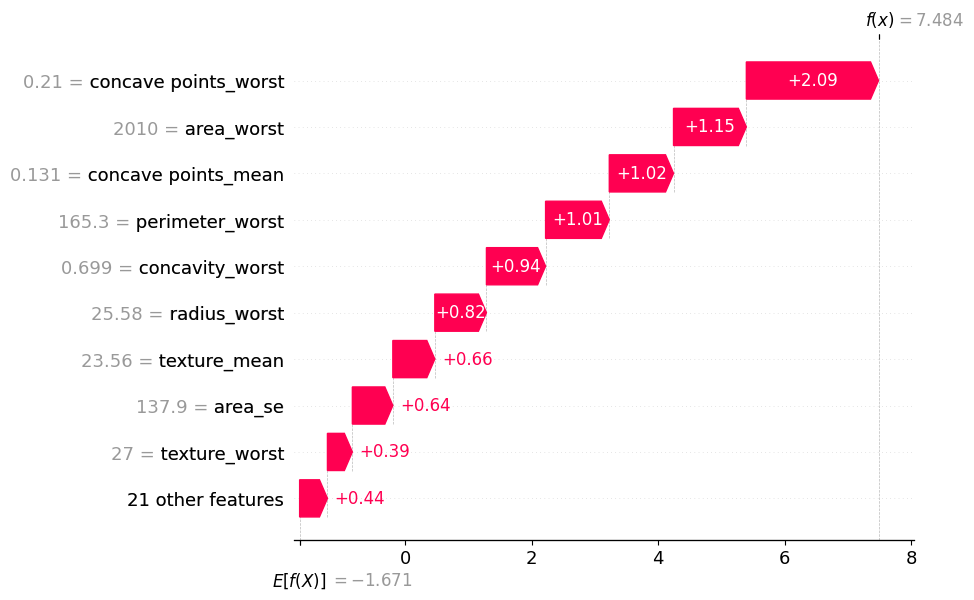

--- true B (benign) index in test (positional): 0 ---


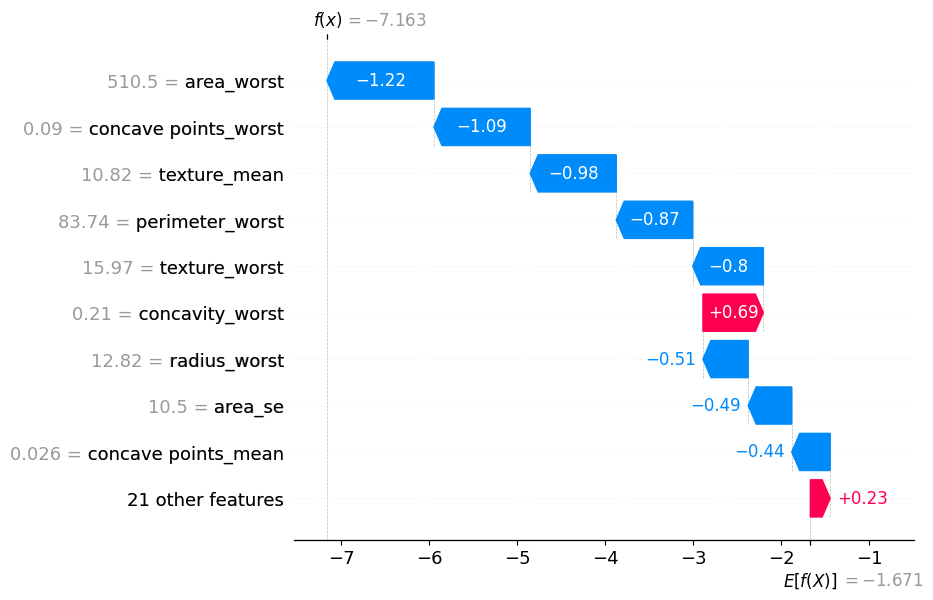

In [10]:
def _first_index(mask):
    idx = np.flatnonzero(mask.to_numpy() if hasattr(mask, "to_numpy") else mask)
    return int(idx[0]) if len(idx) else None


idx_m = _first_index(y_test.reset_index(drop=True) == 1)
idx_b = _first_index(y_test.reset_index(drop=True) == 0)
assert idx_m is not None and idx_b is not None

X_loc = X_test.reset_index(drop=True)

for label, idx in [("true M (malignant)", idx_m), ("true B (benign)", idx_b)]:
    x_one = X_loc.iloc[[idx]]
    ex = explainer(x_one, check_additivity=False)
    print("---", label, "index in test (positional):", idx, "---")
    shap.plots.waterfall(ex[0], show=True)

### Вывод

Локальная интерпретация показывает, что для объекта с истинным классом `M` ключевые признаки (`concave points_worst`, `area_worst`, `concave points_mean`, `perimeter_worst`, `concavity_worst`) в сумме существенно увеличивают выход модели (положительные SHAP-вклады), что приводит к уверенной классификации как злокачественного случая. Для объекта с истинным классом `B` те же информативные признаки в основном дают отрицательные вклады и снижают выход модели, формируя предсказание в сторону доброкачественного класса. Таким образом, решения модели на конкретных пациентах прозрачны и согласованы с медицински осмысленными признаками.

## 8) Мнение об интерпретации

В клинической постановке диагностики опухолей молочной железы доминируют **морфометрия и текстура** опухоли: радиус, периметр, площадь и показатели «worst» отражают размер и агрессивность узла, **вогнутость (concavity)** и **вогнутые точки контура** связаны с неровными, инвазивными границами — ожидаемо они часто в топе важности. Совпадение этого с тем, что усиливает модель для предсказания `M`, повышает доверие к решениям бустинга, при этом модель остаётся статистической эвристикой и не заменяет гистологию и врача.


## 9) Краткая сводка

- Подобраны гиперпараметры `HistGradientBoostingClassifier` под **recall** на стратифицированной CV.
- Финальная оценка — на **test** той же разбивки, что в ДЗ 2, с той же основной метрикой **Recall(M)**.
- Глобальные и локальные объяснения согласованы с медицинской интуицией по признакам Wisconsin dataset; для сдачи дополните при необходимости скриншотами графиков из Jupyter.
